# 🚀 Simple MobileNetV3 Plant Disease Detection
**Load** → **Train** → **Predict** với auto-continue training

In [2]:
# IMPORTS
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v3_large
from PIL import Image
import os
import numpy as np
from tqdm.notebook import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [11]:
# MODEL DEFINITION
class SimpleMobileNetV3(nn.Module):
    def __init__(self, num_classes):
        super(SimpleMobileNetV3, self).__init__()
        self.mobilenet = mobilenet_v3_large(weights='IMAGENET1K_V1')
        # Replace the last layer of the classifier
        in_features = self.mobilenet.classifier[3].in_features
        self.mobilenet.classifier[3] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.mobilenet(x)

# SIMPLE DATASET
class SimpleDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_training=True):
        # Enhanced data augmentation for better accuracy
        if is_training:
            self.transform = transform or transforms.Compose([
                transforms.Resize((256, 256)),  # Larger resize for better crop diversity
                transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Random crop
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.3),  # Useful for plant diseases
                transforms.RandomRotation(degrees=30),  # Disease orientation varies
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
                transforms.RandomAffine(degrees=0, shear=10),  # Slight shear
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                # Add random erasing (cutout) for robustness
                transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3))
            ])
        else:
            # Validation/test transform (no augmentation)
            self.transform = transform or transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
        
        self.samples = []
        self.classes = []
        
        if os.path.exists(root_dir):
            for class_name in os.listdir(root_dir):
                class_path = os.path.join(root_dir, class_name)
                if os.path.isdir(class_path):
                    self.classes.append(class_name)
                    class_idx = len(self.classes) - 1
                    
                    # Load ALL files - no limits
                    files = [f for f in os.listdir(class_path) 
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    
                    for file in files:
                        self.samples.append((os.path.join(class_path, file), class_idx))
        
        print(f"Loaded {len(self.samples)} samples, {len(self.classes)} classes")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            # Return black image on error
            return torch.zeros(3, 224, 224), label

print("Model and Dataset defined!")

Model and Dataset defined!


In [12]:
# CHECKPOINT MANAGEMENT
CHECKPOINT_DIR = "./modelsCP"
FOUNDATION_PATH = f"{CHECKPOINT_DIR}/mobilenet_foundation/mobilenet_foundation_best.pth"
FINETUNE_PATH = f"{CHECKPOINT_DIR}/mobilenet_finetune/mobilenet_finetune_best.pth"

def save_checkpoint(model, acc, class_names, path, info=""):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'model_state_dict': model.state_dict(),
        'accuracy': acc,
        'class_names': class_names,
        'num_classes': len(class_names),
        'timestamp': time.time()
    }, path)
    print(f"✅ Saved {info}: {acc:.2f}% - {path}")

def load_checkpoint(path, num_classes):
    if os.path.exists(path):
        print(f"📂 Loading checkpoint: {path}")
        try:
            checkpoint = torch.load(path, map_location=device, weights_only=True)
            
            model = SimpleMobileNetV3(num_classes=checkpoint['num_classes']).to(device)
            model.load_state_dict(checkpoint['model_state_dict'])
            
            print(f"✅ Loaded - Acc: {checkpoint['accuracy']:.2f}%, Classes: {checkpoint['num_classes']}")
            return model, checkpoint['class_names'], checkpoint['accuracy']
        except Exception as e:
            print(f"❌ Checkpoint incompatible: {e}")
            print("🗑️ Removing old checkpoint...")
            os.remove(path)
            return None, [], 0.0
    return None, [], 0.0

print("Checkpoint functions ready!")

Checkpoint functions ready!


In [13]:
# LOAD PLANT DISEASE DATASET
plant_dataset = SimpleDataset("./dataset/PlantVillage/color", is_training=True)  # For training data
plant_classes = plant_dataset.classes

# Split dataset properly
train_size = int(0.8 * len(plant_dataset))
val_size = len(plant_dataset) - train_size

# Create proper random split
train_dataset, val_dataset_temp = torch.utils.data.random_split(plant_dataset, [train_size, val_size])

# Create validation dataset without augmentation
val_dataset = SimpleDataset("./dataset/PlantVillage/color", is_training=False)
val_indices = list(range(train_size, len(val_dataset)))
val_dataset = torch.utils.data.Subset(val_dataset, val_indices)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"📊 Train: {train_size}, Val: {val_size}, Classes: {len(plant_classes)}")
print("✅ Enhanced data augmentation applied for training!")

Loaded 54305 samples, 38 classes
Loaded 54305 samples, 38 classes
📊 Train: 43444, Val: 10861, Classes: 38
✅ Enhanced data augmentation applied for training!


In [3]:
# 🎯 LOAD - All-in-One Setup với Foundation/Finetune Logic
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset, Subset
from torchvision import transforms
from torchvision.models import mobilenet_v3_large
from PIL import Image
import os
import numpy as np
from tqdm.notebook import tqdm
import time
import torch.nn.functional as F

print("🚀 STARTING LOAD PROCESS...")
print("=" * 50)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

# Model definition
class SimpleMobileNetV3(nn.Module):
    def __init__(self, num_classes):
        super(SimpleMobileNetV3, self).__init__()
        self.mobilenet = mobilenet_v3_large(weights='IMAGENET1K_V1')
        in_features = self.mobilenet.classifier[3].in_features
        self.mobilenet.classifier[3] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.mobilenet(x)

# Enhanced Dataset class với progress tracking
class SimpleDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_training=True, name="Dataset"):
        print(f"📁 Loading {name} from: {root_dir}")
        
        if is_training:
            self.transform = transform or transforms.Compose([
                transforms.Resize((256, 256)),
                transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.3),
                transforms.RandomRotation(degrees=30),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3))
            ])
        else:
            self.transform = transform or transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
        
        self.samples = []
        self.classes = []
        
        if os.path.exists(root_dir):
            class_dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
            print(f"   📂 Found {len(class_dirs)} classes")
            
            class_pbar = tqdm(class_dirs, desc=f"   🔄 Loading {name} classes", ncols=80)
            
            total_files = 0
            for class_name in class_pbar:
                class_path = os.path.join(root_dir, class_name)
                self.classes.append(class_name)
                class_idx = len(self.classes) - 1
                
                files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                for file in files:
                    self.samples.append((os.path.join(class_path, file), class_idx))
                    total_files += 1
                
                class_pbar.set_postfix({'Class': class_name[:15], 'Files': len(files), 'Total': total_files})
            
            print(f"   ✅ {name}: {len(self.samples)} samples, {len(self.classes)} classes")
        else:
            print(f"   ❌ {name}: Path not found - {root_dir}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            return torch.zeros(3, 224, 224), label

# Checkpoint management - FIXED PATHS
CHECKPOINT_DIR = "./modelsCP"
FOUNDATION_PATH = f"{CHECKPOINT_DIR}/mobilenet_foundation/mobilenet_foundation_best.pth"
FINETUNE_PATH = f"{CHECKPOINT_DIR}/mobilenet_finetune/mobilenet_finetune_best.pth"

def save_checkpoint(model, acc, class_names, path, info=""):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'model_state_dict': model.state_dict(),
        'accuracy': acc,
        'class_names': class_names,
        'num_classes': len(class_names),
        'timestamp': time.time()
    }, path)
    print(f"✅ Saved {info}: {acc:.2f}% - {path}")

def load_checkpoint(path, model):
    if os.path.exists(path):
        print(f"📂 Loading checkpoint: {path}")
        try:
            checkpoint = torch.load(path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"   ✅ Checkpoint loaded successfully!")
            print(f"   📊 Accuracy: {checkpoint['accuracy']:.2f}%")
            print(f"   🎯 Classes: {checkpoint['num_classes']}")
            return model, checkpoint['class_names'], checkpoint['accuracy']
        except Exception as e:
            print(f"   ❌ Error loading checkpoint: {e}")
            return None, [], 0.0
    else:
        print(f"   ℹ️  No checkpoint found at: {path}")
    return None, [], 0.0

# Load datasets
print("\n📦 LOADING DATASETS...")
print("=" * 50)
train_plant_dataset = SimpleDataset("./dataset/PlantVillage/color", is_training=True, name="PlantVillage (Train)")
train_durian_dataset = SimpleDataset("./dataset/Durian_Leaf_Diseases/train", is_training=True, name="Durian (Train)")
val_plant_dataset = SimpleDataset("./dataset/PlantVillage/color", is_training=False, name="PlantVillage (Val)")
val_durian_dataset = SimpleDataset("./dataset/Durian_Leaf_Diseases/val", is_training=False, name="Durian (Val)")

# Combine class names and create unified validation set
print(f"\n🔗 COMBINING DATASETS...")
all_class_names = train_plant_dataset.classes + train_durian_dataset.classes
total_classes = len(all_class_names)
print(f"   ✅ Combined classes: {total_classes} total")

class DurianValAdjusted(Dataset):
    def __init__(self, dataset, offset):
        self.dataset = dataset
        self.offset = offset
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        data, label = self.dataset[idx]
        return data, label + self.offset

val_durian_adjusted = DurianValAdjusted(val_durian_dataset, offset=len(train_plant_dataset.classes))
plant_val_size = int(0.2 * len(val_plant_dataset))
plant_val_indices = torch.randperm(len(val_plant_dataset))[:plant_val_size]
plant_val_subset = Subset(val_plant_dataset, plant_val_indices)
combined_val_dataset = ConcatDataset([plant_val_subset, val_durian_adjusted])
val_loader = DataLoader(combined_val_dataset, batch_size=32, shuffle=False, num_workers=0)
print(f"   ✅ Created unified validation set: {len(combined_val_dataset)} samples")

# SMART MODEL LOADING LOGIC
print(f"\n🤖 SMART MODEL LOADING...")
print("=" * 50)
model, class_names, current_accuracy, training_stage, MODEL_PATH = None, [], 0.0, "", ""

print("🔍 Step 1: Checking for FINETUNE model...")
finetune_model_to_load = SimpleMobileNetV3(total_classes).to(device)
loaded_model, loaded_class_names, loaded_acc = load_checkpoint(FINETUNE_PATH, finetune_model_to_load)

if loaded_model is not None:
    print("🎉 FINETUNE model found! Ready to continue training or predict.")
    model, class_names, current_accuracy = loaded_model, loaded_class_names, loaded_acc
    MODEL_PATH, training_stage = FINETUNE_PATH, "FINETUNE_CONTINUE"
else:
    print("\n🔍 Step 2: Checking for FOUNDATION model...")
    foundation_model_to_load = SimpleMobileNetV3(len(train_plant_dataset.classes)).to(device)
    loaded_model, loaded_class_names, loaded_acc = load_checkpoint(FOUNDATION_PATH, foundation_model_to_load)
    
    if loaded_model is not None:
        print("🏗️  FOUNDATION model found! Will proceed to finetune stage.")
        model = SimpleMobileNetV3(total_classes).to(device)
        with torch.no_grad():
            for name, param in loaded_model.named_parameters():
                if 'classifier.3' not in name:
                    model.state_dict()[name].copy_(param)
            old_head_weight = loaded_model.mobilenet.classifier[3].weight.data
            old_head_bias = loaded_model.mobilenet.classifier[3].bias.data
            nn.init.normal_(model.mobilenet.classifier[3].weight, std=0.01)
            nn.init.zeros_(model.mobilenet.classifier[3].bias)
            model.mobilenet.classifier[3].weight.data[:len(train_plant_dataset.classes)] = old_head_weight
            model.mobilenet.classifier[3].bias.data[:len(train_plant_dataset.classes)] = old_head_bias
        
        class_names, current_accuracy = all_class_names, 0.0
        MODEL_PATH, training_stage = FINETUNE_PATH, "FINETUNE_FROM_FOUNDATION"
        print("   ✅ Model rebuilt for combined training!")
    else:
        print("\n🚀 Step 3: No checkpoints found. Creating NEW model...")
        model = SimpleMobileNetV3(len(train_plant_dataset.classes)).to(device)
        current_accuracy, class_names = 0.0, train_plant_dataset.classes
        MODEL_PATH, training_stage = FOUNDATION_PATH, "FOUNDATION_NEW"
        print(f"   ✅ New foundation model created successfully!")

# Model info
print(f"\n📋 MODEL SUMMARY:")
print("=" * 50)
print(f"🎯 Current accuracy: {current_accuracy:.2f}%")
print(f"🔢 Total classes in model: {model.mobilenet.classifier[3].out_features}")
print(f"💾 Model save path: {MODEL_PATH}")
print(f"🚀 Next training stage: {training_stage}")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🧠 Parameters: Total: {total_params:,}, Trainable: {trainable_params:,}")
print(f"\n🎉 LOAD COMPLETE!")
print("=" * 50)
print("🔄 Ready for training or prediction!")


🚀 STARTING LOAD PROCESS...
🖥️  Device: cuda

📦 LOADING DATASETS...
📁 Loading PlantVillage (Train) from: ./dataset/PlantVillage/color
   📂 Found 38 classes


   🔄 Loading PlantVillage (Train) classes:   0%|        | 0/38 [00:00<?, ?it/s]

   ✅ PlantVillage (Train): 54305 samples, 38 classes
📁 Loading Durian (Train) from: ./dataset/Durian_Leaf_Diseases/train
   📂 Found 6 classes


   🔄 Loading Durian (Train) classes:   0%|               | 0/6 [00:00<?, ?it/s]

   ✅ Durian (Train): 1814 samples, 6 classes
📁 Loading PlantVillage (Val) from: ./dataset/PlantVillage/color
   📂 Found 38 classes


...

   ✅ PlantVillage (Val): 54305 samples, 38 classes
📁 Loading Durian (Val) from: ./dataset/Durian_Leaf_Diseases/val
   📂 Found 6 classes


   🔄 Loading Durian (Val) classes:   0%|                 | 0/6 [00:00<?, ?it/s]

   ✅ Durian (Val): 387 samples, 6 classes

🔗 COMBINING DATASETS...
   ✅ Combined classes: 44 total
   ✅ Created unified validation set: 11248 samples

🤖 SMART MODEL LOADING...
🔍 Step 1: Checking for FINETUNE model...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to C:\Users\dltv2/.cache\torch\hub\checkpoints\mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 69.7MB/s]



📂 Loading checkpoint: ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth
   ✅ Checkpoint loaded successfully!
   📊 Accuracy: 93.83%
   🎯 Classes: 44
🎉 FINETUNE model found! Ready to continue training or predict.

📋 MODEL SUMMARY:
🎯 Current accuracy: 93.83%
🔢 Total classes in model: 44
💾 Model save path: ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth
🚀 Next training stage: FINETUNE_CONTINUE
🧠 Parameters: Total: 4,258,396, Trainable: 4,258,396

🎉 LOAD COMPLETE!
🔄 Ready for training or prediction!


In [ ]:
# 🚀 TRAIN - Foundation → Finetune Training

# ⚙️ TRAINING CONFIGURATION - EDIT HERE
FOUNDATION_EPOCHS = 15  # ✏️ Foundation training epochs (PlantVillage only)
FINETUNE_EPOCHS = 5   # ✏️ Finetune training epochs (PlantVillage + Durian)

import sys
import time

def print_immediate(text):
    """Print immediately without buffering"""
    print(text)
    sys.stdout.flush()

print_immediate(f"🔧 TRAINING CONFIG:")
print_immediate(f"   🏗️  Foundation: {FOUNDATION_EPOCHS} epochs")
print_immediate(f"   🎯 Finetune: {FINETUNE_EPOCHS} epochs")
print_immediate("=" * 60)

def train_foundation(epochs):
    """
    Train Foundation model - PlantVillage only
    """
    global model, current_accuracy
    print_immediate(f"\n🏗️  FOUNDATION TRAINING ({len(train_plant_dataset.classes)} classes) for {epochs} epochs...")

    foundation_loader = DataLoader(train_plant_dataset, batch_size=64, shuffle=True, num_workers=0)

    model.train()
    for name, param in model.named_parameters():
        param.requires_grad = 'classifier.3' in name
    
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    best_acc = current_accuracy
    
    for epoch in range(epochs):
        model.train()
        running_loss, train_correct, train_total = 0.0, 0, 0
        
        train_pbar = tqdm(foundation_loader, desc=f"🏗️  Foundation Epoch {epoch+1}/{epochs}", ncols=120, leave=True)
        
        for data, targets in train_pbar:
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()
            
            train_pbar.set_postfix({
                'Loss': f'{running_loss / (train_pbar.n + 1):.4f}',
                'Acc': f'{100. * train_correct / train_total:.2f}%',
                'LR': f'{scheduler.get_last_lr()[0]:.2e}'
            })
        
        train_acc = 100. * train_correct / train_total
        scheduler.step()
        
        if train_acc > best_acc:
            best_acc = train_acc
            current_accuracy = best_acc
            save_checkpoint(model, current_accuracy, train_plant_dataset.classes, FOUNDATION_PATH, f"Foundation Epoch {epoch+1}")
    
    print_immediate(f"✅ Foundation training complete! Best Accuracy: {best_acc:.2f}%")
    return best_acc

def train_finetune(epochs):
    """
    Train Finetune model - PlantVillage + Durian
    """
    global model, current_accuracy
    print_immediate(f"\n🎯 FINETUNE TRAINING ({len(all_class_names)} classes) for {epochs} epochs...")
    
    if model.mobilenet.classifier[3].out_features != len(all_class_names):
        print_immediate("❌ Model architecture mismatch for finetuning. Aborting.")
        return 0.0

    plant_subset_size = len(train_durian_dataset)
    plant_indices = torch.randperm(len(train_plant_dataset))[:plant_subset_size]
    plant_subset = Subset(train_plant_dataset, plant_indices)
    
    class DurianTrainAdjusted(Dataset):
        def __init__(self, dataset, offset):
            self.dataset = dataset
            self.offset = offset
        def __len__(self): return len(self.dataset)
        def __getitem__(self, idx):
            data, label = self.dataset[idx]
            return data, label + self.offset
            
    durian_adjusted = DurianTrainAdjusted(train_durian_dataset, offset=len(train_plant_dataset.classes))
    combined_train_dataset = ConcatDataset([plant_subset, durian_adjusted])
    finetune_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=True, num_workers=0)
    
    model.train()
    for param in model.parameters():
        param.requires_grad = True
        
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)
    
    best_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        running_loss, train_correct, train_total = 0.0, 0, 0
        
        train_pbar = tqdm(finetune_loader, desc=f"🎯 Finetune Epoch {epoch+1}/{epochs}", ncols=120, leave=True)
        
        for data, targets in train_pbar:
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()
            
            train_pbar.set_postfix({
                'Loss': f'{running_loss / (train_pbar.n + 1):.4f}',
                'Acc': f'{100. * train_correct / train_total:.2f}%',
                'LR': f'{scheduler.get_last_lr()[0]:.2e}'
            })
            
        train_acc = 100. * train_correct / train_total
        scheduler.step()
        
        if train_acc > best_acc:
            best_acc = train_acc
            current_accuracy = best_acc
            save_checkpoint(model, current_accuracy, all_class_names, FINETUNE_PATH, f"Finetune Epoch {epoch+1}")

    print_immediate(f"✅ Finetune training complete! Best Accuracy: {best_acc:.2f}%")
    return best_acc

# 🚀 TRAINING PIPELINE
print_immediate("🚀 STARTING TRAINING PIPELINE...")

if training_stage == "FOUNDATION_NEW":
    train_foundation(FOUNDATION_EPOCHS)
    print("\n🔄 Reloading model to prepare for finetuning...")
    foundation_model_to_load = SimpleMobileNetV3(len(train_plant_dataset.classes)).to(device)
    model, class_names, current_accuracy = load_checkpoint(FOUNDATION_PATH, foundation_model_to_load)
    training_stage = "FINETUNE_FROM_FOUNDATION"
    
    if model is not None:
        print("   🔧 Rebuilding model for combined classes...")
        old_model = model
        model = SimpleMobileNetV3(total_classes).to(device)
        with torch.no_grad():
            for name, param in old_model.named_parameters():
                if 'classifier.3' not in name:
                    model.state_dict()[name].copy_(param)
            old_head_weight = old_model.mobilenet.classifier[3].weight.data
            old_head_bias = old_model.mobilenet.classifier[3].bias.data
            nn.init.normal_(model.mobilenet.classifier[3].weight, std=0.01)
            nn.init.zeros_(model.mobilenet.classifier[3].bias)
            model.mobilenet.classifier[3].weight.data[:len(train_plant_dataset.classes)] = old_head_weight
            model.mobilenet.classifier[3].bias.data[:len(train_plant_dataset.classes)] = old_head_bias
        class_names = all_class_names
        print("   ✅ Model rebuilt and ready for finetuning!")

if training_stage in ["FINETUNE_FROM_FOUNDATION", "FINETUNE_CONTINUE"]:
    print_immediate("\n🚀 Proceeding to Finetune Training...")
    train_finetune(FINETUNE_EPOCHS)
elif training_stage == "FOUNDATION_NEW":
     print_immediate("Foundation training was just completed. Now starting finetune.")
     train_finetune(FINETUNE_EPOCHS)
else:
    print_immediate(f"ℹ️ Skipping training. Current stage: '{training_stage}'")

print_immediate("\n🎉 TRAINING PIPELINE COMPLETED!")


🔧 TRAINING CONFIG:
   🏗️  Foundation: 15 epochs
   🎯 Finetune: 5 epochs
🚀 STARTING TRAINING PIPELINE...

🏗️  FOUNDATION TRAINING (38 classes) for 15 epochs...


🏗️  Foundation Epoch 1/15:   0%|                                                                | 0/849 [00:00…

✅ Saved Foundation Epoch 1: 86.44% - ./modelsCP/mobilenet_foundation/mobilenet_foundation_best.pth


🏗️  Foundation Epoch 2/15:   0%|                                                                | 0/849 [00:00…

✅ Saved Foundation Epoch 2: 91.35% - ./modelsCP/mobilenet_foundation/mobilenet_foundation_best.pth


...

✅ Saved Finetune Epoch 3: 91.35% - ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth


🎯 Finetune Epoch 4/5:   0%|                                                                    | 0/114 [00:00<…

✅ Saved Finetune Epoch 4: 93.44% - ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth


🎯 Finetune Epoch 5/5:   0%|                                                                    | 0/114 [00:00<…

✅ Saved Finetune Epoch 5: 93.83% - ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth
✅ Finetune training complete! Best Accuracy: 93.83%

🎉 TRAINING PIPELINE COMPLETED!


In [16]:
# 🔮 PREDICT - Load Finetune Model & Predict

print("🔮 LOADING FINETUNE MODEL FOR PREDICTION...")
print("=" * 60)

# Import required libraries for prediction
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os

# Load finetune model
predict_model = None
predict_class_names = []
predict_accuracy = 0.0

print("📂 Loading finetune model...")
if os.path.exists(FINETUNE_PATH):
    try:
        print("   🔄 Reading finetune checkpoint...")
        checkpoint = torch.load(FINETUNE_PATH, map_location=device, weights_only=True)
        
        print("   🏗️  Building prediction model...")
        predict_model = SimpleMobileNetV3(num_classes=checkpoint['num_classes']).to(device)
        predict_model.load_state_dict(checkpoint['model_state_dict'])
        
        predict_class_names = checkpoint['class_names']
        predict_accuracy = checkpoint['accuracy']
        
        print(f"   ✅ Finetune model loaded!")
        print(f"   📊 Accuracy: {predict_accuracy:.2f}%")
        print(f"   🎯 Classes: {len(predict_class_names)}")
    except Exception as e:
        print(f"   ❌ Error loading finetune model: {e}")
        # Fallback to current model if exists
        if 'model' in globals():
            predict_model = model
            predict_class_names = all_class_names if 'all_class_names' in globals() else class_names
            predict_accuracy = current_accuracy if 'current_accuracy' in globals() else 0.0
            print("   🔄 Using current model as fallback")
        else:
            print("   ❌ No model available for prediction")
            predict_model = None
else:
    print("   ⚠️  Finetune model not found")
    # Fallback to current model if exists
    if 'model' in globals():
        predict_model = model
        predict_class_names = all_class_names if 'all_class_names' in globals() else class_names
        predict_accuracy = current_accuracy if 'current_accuracy' in globals() else 0.0
        print("   🔄 Using current model as fallback")
    else:
        print("   ❌ No model available for prediction")
        predict_model = None

if predict_model is not None:
    print(f"🎯 Prediction ready with {predict_accuracy:.2f}% accuracy model")
    print(f"📊 Total classes: {len(predict_class_names)}")
else:
    print("❌ No model available for prediction. Please train a model first.")
print("=" * 60)

def simple_predict(image_path, show_details=True):
    """
    Simple prediction with finetune model and bias correction
    Xử lý ảnh giống như trong training để đảm bảo consistency
    """
    
    global predict_model, predict_class_names, predict_accuracy
    
    if predict_model is None:
        return {'error': 'No model loaded for prediction', 'success': False}
    
    if not os.path.exists(image_path):
        return {'error': f'Image not found: {image_path}', 'success': False}
    
    try:
        # Load and preprocess image - GIỐNG NHƯ TRAINING
        image = Image.open(image_path).convert('RGB')
        
        # Transform giống như validation trong training (không augmentation)
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        tensor = transform(image).unsqueeze(0).to(device)
        
        # Predict with finetune model
        predict_model.eval()
        with torch.no_grad():
            outputs = predict_model(tensor)
            
            # Bias correction: reduce Durian scores by 30% (nếu cần)
            if 'plant_dataset' in globals():
                plant_classes_count = len(plant_dataset.classes)
                if outputs.shape[1] > plant_classes_count:
                    outputs[:, plant_classes_count:] *= 0.7
            
            # Get prediction
            probabilities = F.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            
            pred_idx = predicted.item()
            confidence_score = confidence.item() * 100
            
            # Get class info
            pred_class = predict_class_names[pred_idx] if pred_idx < len(predict_class_names) else f"Unknown_{pred_idx}"
            
            # Determine type based on class index
            if 'plant_dataset' in globals():
                plant_classes_count = len(plant_dataset.classes)
                pred_type = "PlantVillage" if pred_idx < plant_classes_count else "Durian"
            else:
                pred_type = "Unknown"
            
            # Format result
            formatted_class = pred_class.replace('___', ' - ').replace('_', ' ')
            
            result = {
                'class': formatted_class,
                'confidence': confidence_score,
                'type': pred_type,
                'model_accuracy': predict_accuracy,
                'success': True,
                'filename': os.path.basename(image_path)
            }
            
            if show_details:
                type_emoji = "🌱" if pred_type == "PlantVillage" else "🥥" if pred_type == "Durian" else "❓"
                conf_emoji = "🔥" if confidence_score > 80 else "⭐" if confidence_score > 60 else "🔶" if confidence_score > 40 else "⚠️"
                
                print(f"\n🔮 PLANT DISEASE PREDICTION")
                print(f"📁 File: {os.path.basename(image_path)}")
                print(f"{type_emoji} Disease: {formatted_class}")
                print(f"{conf_emoji} Confidence: {confidence_score:.1f}%")
                print(f"📊 Type: {pred_type}")
                print(f"🎯 Model Accuracy: {predict_accuracy:.1f}%")
            
            return result
            
    except Exception as e:
        return {'error': str(e), 'success': False}

def test_real_images(folder="./realImage", max_images=8):
    """Test real plant disease images"""
    
    if not os.path.exists(folder):
        print(f"❌ Folder not found: {folder}")
        return []
    
    image_files = [f for f in os.listdir(folder) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:max_images]
    
    if not image_files:
        print(f"❌ No images found in {folder}")
        return []
    
    print(f"🌟 TESTING REAL PLANT DISEASE IMAGES")
    print(f"📁 Folder: {folder}")
    print(f"🖼️  Testing {len(image_files)} images")
    print("=" * 70)
    
    results = []
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder, image_file)
        
        print(f"\n📸 {i+1:2d}. {image_file}")
        result = simple_predict(image_path, show_details=False)
        
        if result['success']:
            results.append(result)
            type_emoji = "🌱" if result['type'] == "PlantVillage" else "🥥" if result['type'] == "Durian" else "❓"
            conf_emoji = "🔥" if result['confidence'] > 80 else "⭐" if result['confidence'] > 60 else "🔶"
            
            print(f"     {type_emoji} {conf_emoji} {result['confidence']:5.1f}% - {result['class']}")
        else:
            print(f"     ❌ Error: {result['error']}")
    
    return results

def test_durian_validation(durian_val_folder="./dataset/Durian_Leaf_Diseases/val", max_per_class=3):
    """Test durian validation set"""
    
    if not os.path.exists(durian_val_folder):
        print(f"❌ Durian validation folder not found: {durian_val_folder}")
        return []
    
    print(f"\n🥥 TESTING DURIAN VALIDATION SET")
    print(f"📁 Folder: {durian_val_folder}")
    print(f"🖼️  Testing up to {max_per_class} images per class")
    print("=" * 70)
    
    all_results = []
    
    for class_name in sorted(os.listdir(durian_val_folder)):
        class_path = os.path.join(durian_val_folder, class_name)
        if os.path.isdir(class_path):
            print(f"\n📂 Class: {class_name}")
            
            # Test images per class
            image_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:max_per_class]
            
            class_results = []
            for i, image_file in enumerate(image_files):
                image_path = os.path.join(class_path, image_file)
                
                print(f"   📸 {i+1}. {image_file}")
                result = simple_predict(image_path, show_details=False)
                
                if result['success']:
                    class_results.append(result)
                    all_results.append(result)
                    
                    # Check if prediction matches true class
                    predicted_class = result['class'].lower()
                    true_class = class_name.lower()
                    is_correct = any(word in predicted_class for word in true_class.split('_'))
                    correct_emoji = "✅" if is_correct else "❌"
                    
                    type_emoji = "🌱" if result['type'] == "PlantVillage" else "🥥" if result['type'] == "Durian" else "❓"
                    conf_emoji = "🔥" if result['confidence'] > 80 else "⭐" if result['confidence'] > 60 else "🔶"
                    
                    print(f"       {type_emoji} {conf_emoji} {result['confidence']:5.1f}% {correct_emoji} {result['class']}")
                else:
                    print(f"       ❌ Error: {result['error']}")
            
            # Class summary
            if class_results:
                avg_conf = sum(r['confidence'] for r in class_results) / len(class_results)
                durian_count = sum(1 for r in class_results if r['type'] == 'Durian')
                correct_count = sum(1 for r in class_results 
                                  if any(word in r['class'].lower() for word in class_name.lower().split('_')))
                
                print(f"   📊 Summary: Avg conf: {avg_conf:.1f}%, Durian: {durian_count}/{len(class_results)}, Correct: {correct_count}/{len(class_results)}")
    
    return all_results

def comprehensive_prediction_test():
    """Comprehensive prediction test for both real images and durian validation"""
    
    print("🎯 COMPREHENSIVE PREDICTION TEST")
    print("=" * 80)
    
    all_results = []
    
    # Test 1: Real Plant Disease Images
    print("\n🌟 PHASE 1: REAL PLANT DISEASE IMAGES")
    real_results = test_real_images("./realImage", max_images=8)
    all_results.extend(real_results)
    
    # Test 2: Durian Validation Set
    print("\n🥥 PHASE 2: DURIAN VALIDATION SET")
    durian_results = test_durian_validation("./dataset/Durian_Leaf_Diseases/val", max_per_class=3)
    all_results.extend(durian_results)
    
    # Overall Summary
    if all_results:
        print(f"\n📊 COMPREHENSIVE SUMMARY")
        print("=" * 80)
        
        total_tests = len(all_results)
        plant_count = sum(1 for r in all_results if r['type'] == 'PlantVillage')
        durian_count = sum(1 for r in all_results if r['type'] == 'Durian')
        unknown_count = sum(1 for r in all_results if r['type'] == 'Unknown')
        high_conf = sum(1 for r in all_results if r['confidence'] > 70)
        avg_conf = sum(r['confidence'] for r in all_results) / total_tests
        
        print(f"📈 Total predictions: {total_tests}")
        print(f"🔥 High confidence (>70%): {high_conf}/{total_tests} ({high_conf/total_tests*100:.1f}%)")
        print(f"⭐ Average confidence: {avg_conf:.1f}%")
        print(f"🌱 PlantVillage predictions: {plant_count} ({plant_count/total_tests*100:.1f}%)")
        print(f"🥥 Durian predictions: {durian_count} ({durian_count/total_tests*100:.1f}%)")
        if unknown_count > 0:
            print(f"❓ Unknown predictions: {unknown_count} ({unknown_count/total_tests*100:.1f}%)")
        
        # Bias assessment
        total_known = plant_count + durian_count
        if total_known > 0:
            plant_ratio = plant_count / total_known
            durian_ratio = durian_count / total_known
            
            if abs(plant_ratio - durian_ratio) <= 0.2:  # Within 20%
                print(f"⚖️ Model appears BALANCED ✅")
            elif plant_ratio > durian_ratio:
                print(f"🌱 Model appears PLANT-BIASED ⚠️")
            else:
                print(f"🥥 Model appears DURIAN-BIASED ⚠️")
        
        print(f"\n🎯 Model Performance:")
        print(f"📊 Model Accuracy: {predict_accuracy:.1f}%")
        print(f"💾 Model Path: {FINETUNE_PATH}")
        
    else:
        print("❌ No predictions were made")
    
    return all_results

# ⚡ RUN COMPREHENSIVE PREDICTION TEST
if predict_model is not None:
    print("🔮 STARTING COMPREHENSIVE PREDICTION TEST")
    print(f"🎯 Using finetune model: {predict_accuracy:.1f}% accuracy")
    print(f"📊 Classes available: {len(predict_class_names)}")
    
    results = comprehensive_prediction_test()
    
    print(f"\n✅ PREDICTION TESTING COMPLETE!")
    print(f"🏆 Total predictions made: {len(results)}")
    print(f"📁 Model used: {FINETUNE_PATH}")
    print(f"🎯 Model accuracy: {predict_accuracy:.1f}%")
else:
    print("❌ Cannot run prediction test - no model loaded")
    print("💡 Please run the LOAD and TRAIN cells first to create a model")

🔮 LOADING FINETUNE MODEL FOR PREDICTION...
📂 Loading finetune model...
   🔄 Reading finetune checkpoint...
   🏗️  Building prediction model...
   ✅ Finetune model loaded!
   📊 Accuracy: 93.83%
   🎯 Classes: 44
🎯 Prediction ready with 93.83% accuracy model
📊 Total classes: 44
🔮 STARTING COMPREHENSIVE PREDICTION TEST
🎯 Using finetune model: 93.8% accuracy
📊 Classes available: 44
🎯 COMPREHENSIVE PREDICTION TEST

🌟 PHASE 1: REAL PLANT DISEASE IMAGES
🌟 TESTING REAL PLANT DISEASE IMAGES
📁 Folder: ./realImage
🖼️  Testing 8 images

📸  1. 8b_strawberry_leaf_scorch_strang_uk_09hort002js309.jpg
     🌱 🔥 100.0% - Strawberry - Leaf scorch

📸  2. bacterial-spot-of-pepper-pepper-1560240277.jpg
     🥥 🔶  51.8% - Leaf Phomopsis

📸  3. ca2020_early_blight_potato_damage2.png
     🥥 🔶  57.3% - Leaf Blight

📸  4. can-you-eat-potato-leaves.jpg
     🥥 🔶  35.6% - Leaf Algal

📸  5. corn_common_rust.jpg
     🌱 🔶  43.8% - Corn (maize) - Northern Leaf Blight

📸  6. corn_leaf_blight.jpg
     🥥 🔶  57.4% - Leaf Alga

🏗️  Defining model architecture...
✅ Model architecture defined successfully.
🖥️  Using device: cuda

🔄 LOADING FINETUNE MODEL...
   📂 Reading checkpoint from: ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth
   📊 Found 44 classes in checkpoint.
   🏗️  Rebuilding model with 'SimpleMobileNetV3' wrapper...
   ⚡ Loading weights into model...

✅ MODEL LOADED SUCCESSFULLY!
   🎯 Model Accuracy: 93.83%

🔮 PREDICTING IMAGE 🔮
📁 File: late_blight_tomato_unusual-symptomsx1200.jpg


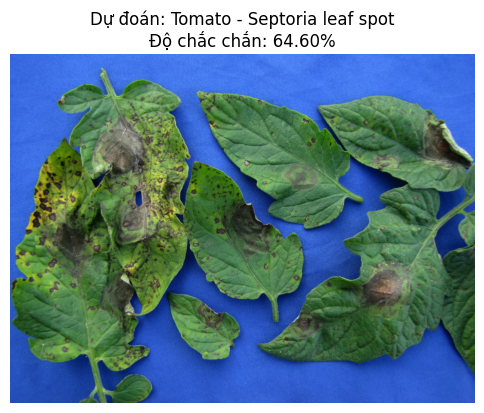

In [17]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import os
import time
import matplotlib.pyplot as plt # <--- THÊM THƯ VIỆN NÀY

# ==============================================================================
# BƯỚC 1: SAO CHÉP Y HỆT ĐỊNH NGHĨA MODEL TỪ FILE TRAINING
# ==============================================================================
print("🏗️  Defining model architecture...")

class SimpleMobileNetV3(nn.Module):
    def __init__(self, num_classes):
        super(SimpleMobileNetV3, self).__init__()
        self.mobilenet = models.mobilenet_v3_large() 
        in_features = self.mobilenet.classifier[3].in_features
        self.mobilenet.classifier[3] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.mobilenet(x)

print("✅ Model architecture defined successfully.")

# ==============================================================================
# BƯỚC 2: HÀM DỰ ĐOÁN (ĐÃ NÂNG CẤP ĐỂ HIỂN THỊ ẢNH)
# ==============================================================================
def predict_single_image(model, image_path, class_names, device):
    """
    Dự đoán trên một file ảnh, in kết quả và hiển thị ảnh.
    """
    if not os.path.exists(image_path):
        print(f"❌ Lỗi: Không tìm thấy ảnh tại đường dẫn '{image_path}'")
        return

    print(f"\n🔮 PREDICTING IMAGE 🔮")
    print(f"📁 File: {os.path.basename(image_path)}")
    
    try:
        # Tải ảnh gốc để hiển thị
        original_image = Image.open(image_path).convert('RGB')
        
        # Tiền xử lý ảnh để đưa vào model
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        tensor = transform(original_image).unsqueeze(0).to(device)
        
        model.eval()
        
        with torch.no_grad():
            outputs = model(tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted_idx_tensor = torch.max(probabilities, 1)
            
            pred_idx = predicted_idx_tensor.item()
            confidence_score = confidence.item() * 100
            pred_class = class_names[pred_idx].replace('___', ' - ').replace('_', ' ')

        # --- PHẦN HIỂN THỊ ẢNH ---
        plt.figure(figsize=(6, 7))
        plt.imshow(original_image)
        
        # Tạo tiêu đề cho ảnh
        title = f"Dự đoán: {pred_class}\n" \
                f"Độ chắc chắn: {confidence_score:.2f}%"
        
        plt.title(title, fontsize=12)
        plt.axis('off') # Ẩn các trục tọa độ
        plt.show() # Hiển thị cửa sổ ảnh
        # --------------------------
        
    except Exception as e:
        print(f"   ❌ Đã xảy ra lỗi trong quá trình dự đoán: {e}")

# ==============================================================================
# BƯỚC 3: KỊCH BẢN CHÍNH - TẢI CHECKPOINT VÀ GỌI HÀM DỰ ĐOÁN
# ==============================================================================
if __name__ == '__main__':
    # --- ⚙️ CẤU HÌNH ---
    FINETUNE_PATH = "./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth"
    IMAGE_TO_PREDICT = "./realImage/late_blight_tomato_unusual-symptomsx1200.jpg" # ✏️ THAY ĐỔI ẢNH CỦA BẠN Ở ĐÂY
    # -----------------
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Using device: {device}")
    
    model = None
    class_names = []
    
    print("\n🔄 LOADING FINETUNE MODEL...")
    print("=" * 50)
    
    if os.path.exists(FINETUNE_PATH):
        try:
            print(f"   📂 Reading checkpoint from: {FINETUNE_PATH}")
            checkpoint = torch.load(FINETUNE_PATH, map_location=device)
            
            num_classes = checkpoint['num_classes']
            print(f"   📊 Found {num_classes} classes in checkpoint.")

            print("   🏗️  Rebuilding model with 'SimpleMobileNetV3' wrapper...")
            model = SimpleMobileNetV3(num_classes=num_classes).to(device)

            print("   ⚡ Loading weights into model...")
            model.load_state_dict(checkpoint['model_state_dict'])
            
            class_names = checkpoint['class_names']
            accuracy = checkpoint.get('accuracy', 0.0)
            
            print("\n✅ MODEL LOADED SUCCESSFULLY!")
            print(f"   🎯 Model Accuracy: {accuracy:.2f}%")
            print("=" * 50)

        except Exception as e:
            print(f"   ❌ FAILED to load checkpoint: {e}")
            model = None
    else:
        print(f"   ❌ Checkpoint file not found at: {FINETUNE_PATH}")

    if model:
        predict_single_image(model, IMAGE_TO_PREDICT, class_names, device)

In [4]:
# ADVANCED EVALUATION - Overall Metrics Summary

import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
import time

print("ADVANCED EVALUATION - OVERALL METRICS")
print("=" * 60)

# Ensure the final finetuned model is loaded
eval_model = None
eval_class_names = []

if 'model' in globals() and model is not None and model.mobilenet.classifier[3].out_features == total_classes:
    eval_model = model
    eval_class_names = all_class_names
    print("[+] Using final trained model from the pipeline.")
else:
    print(">> Loading finetune model for evaluation...")
    if os.path.exists(FINETUNE_PATH):
        try:
            checkpoint = torch.load(FINETUNE_PATH, map_location=device)
            num_classes = checkpoint['num_classes']
            
            # Rebuild model and load weights
            eval_model = SimpleMobileNetV3(num_classes=num_classes).to(device)
            eval_model.load_state_dict(checkpoint['model_state_dict'])
            eval_class_names = checkpoint['class_names']
            
            print(f"   [+] Finetune model loaded successfully ({checkpoint.get('accuracy', 0.0):.2f}% acc).")
        except Exception as e:
            print(f"   [!] Error loading finetune model: {e}")
    else:
        print("   [!] Finetune checkpoint not found. Cannot perform evaluation.")

if eval_model and 'val_loader' in globals():
    # Ensure model and device are properly configured for GPU usage
    print(f">> Using device: {device}")
    print(f">> Model location: {next(eval_model.parameters()).device}")
    
    eval_model.eval()
    all_preds = []
    all_labels = []
    
    # --- Performance Evaluation ---
    print("\n>> Running evaluation on validation set...")
    with torch.no_grad():
        eval_pbar = tqdm(val_loader, desc=">> Evaluating", ncols=100)
        for images, labels in eval_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = eval_model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- OVERALL METRICS CALCULATION ---
    accuracy = accuracy_score(all_labels, all_preds)
    
    # Macro averages (equal weight per class)
    precision_macro = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    # Weighted averages (weighted by support)
    precision_weighted = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall_weighted = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    # --- RESULTS DISPLAY ---
    print(f"\n>> OVERALL MODEL PERFORMANCE SUMMARY")
    print("=" * 60)
    print(f">> Overall Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f">> Overall Precision: {precision_weighted:.4f} ({precision_weighted*100:.2f}%)")
    print(f">> Overall Recall:    {recall_weighted:.4f} ({recall_weighted*100:.2f}%)")
    print(f">> Overall F1-Score:  {f1_weighted:.4f} ({f1_weighted*100:.2f}%)")
    print()
    print(f">> MACRO AVERAGES (equal weight per class):")
    print(f"   >> Precision:  {precision_macro:.4f} ({precision_macro*100:.2f}%)")
    print(f"   >> Recall:     {recall_macro:.4f} ({recall_macro*100:.2f}%)")
    print(f"   >> F1-Score:   {f1_macro:.4f} ({f1_macro*100:.2f}%)")
    print()
    print(f">> WEIGHTED AVERAGES (weighted by support):")
    print(f"   >> Precision:  {precision_weighted:.4f} ({precision_weighted*100:.2f}%)")
    print(f"   >> Recall:     {recall_weighted:.4f} ({recall_weighted*100:.2f}%)")
    print(f"   >> F1-Score:   {f1_weighted:.4f} ({f1_weighted*100:.2f}%)")
    print("=" * 60)
    
    # --- INFERENCE SPEED TEST ---
    print(f"\n>> INFERENCE SPEED TEST (GPU Optimized)")
    print("-" * 40)
    
    # Get a single batch for testing
    sample_batch, _ = next(iter(val_loader))
    sample_batch = sample_batch.to(device)
    
    # Warm-up runs to ensure GPU is ready
    print("   [i] Warming up GPU...")
    for _ in range(10):
        _ = eval_model(sample_batch)
        
    # Synchronize GPU before timing
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        
    # Timed runs
    print("   [i] Running speed test...")
    num_runs = 50
    start_time = time.time()
    for _ in range(num_runs):
        _ = eval_model(sample_batch)
    
    # Synchronize GPU after timing
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end_time = time.time()
    
    total_time = end_time - start_time
    images_per_batch = sample_batch.size(0)
    total_images = num_runs * images_per_batch
    
    avg_time_per_batch = total_time / num_runs
    fps = total_images / total_time
    
    print(f"   >> Batch size: {images_per_batch} images")
    print(f"   >> Speed: {fps:.1f} FPS")
    print(f"   >> Avg time per batch: {avg_time_per_batch * 1000:.1f} ms")
    print("-" * 40)
    
    print(f"\n[+] EVALUATION COMPLETE!")
    print(f">> Key Results: Acc={accuracy*100:.1f}%, Prec={precision_weighted*100:.1f}%, Rec={recall_weighted*100:.1f}%, F1={f1_weighted*100:.1f}%, Speed={fps:.1f}FPS")

else:
    print("[!] Evaluation skipped. Model or validation loader not available.")
    print("[i] Please ensure the model and validation data are loaded properly.")

ADVANCED EVALUATION - OVERALL METRICS
[+] Using final trained model from the pipeline.
>> Using device: cuda
>> Model location: cuda:0

>> Running evaluation on validation set...


>> Evaluating: 100%|██████████████████████████████████████████████| 352/352 [00:40<00:00,  8.70it/s]




>> OVERALL MODEL PERFORMANCE SUMMARY
>> Overall Accuracy:  0.9729 (97.29%)
>> Overall Precision: 0.9740 (97.40%)
>> Overall Recall:    0.9729 (97.29%)
>> Overall F1-Score:  0.9728 (97.28%)

>> MACRO AVERAGES (equal weight per class):
   >> Precision:  0.9631 (96.31%)
   >> Recall:     0.9656 (96.56%)
   >> F1-Score:   0.9630 (96.30%)

>> WEIGHTED AVERAGES (weighted by support):
   >> Precision:  0.9740 (97.40%)
   >> Recall:     0.9729 (97.29%)
   >> F1-Score:   0.9728 (97.28%)

>> INFERENCE SPEED TEST (GPU Optimized)
----------------------------------------
   [i] Warming up GPU...
   [i] Running speed test...
   >> Batch size: 32 images
   >> Speed: 4759.9 FPS
   >> Avg time per batch: 6.7 ms
----------------------------------------

[+] EVALUATION COMPLETE!
>> Key Results: Acc=97.3%, Prec=97.4%, Rec=97.3%, F1=97.3%, Speed=4759.9FPS
   >> Batch size: 32 images
   >> Speed: 4759.9 FPS
   >> Avg time per batch: 6.7 ms
----------------------------------------

[+] EVALUATION COMPLETE!
